# Linear Regression

## Univariate Linear Regression
When you have one variable as input to the function y, we called it Univariate variable

For example, we just have one variable SAT score to predict GPA

In [4]:
url = "https://raw.githubusercontent.com/tehmeerali786/360-Data-Science-/refs/heads/master/1.01.%20Simple%20linear%20regression.csv"
import pandas as pd
data = pd.read_csv(url)
data.head()


,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


Give dataset above, SO the question **with the dataset can we make a function to predict GPA given SAT score ?**, to decide which method to create function to predict GPA, **we must make asumption first relationship between GPA and SAT and then we validate  it using data**

for example, i may assume that there're linear relationship between GPA and SAT score. So after that, we should validate it using data. Assumption Test can be used before we fit model (by generate scatter plot) and after fit the model

### Assumption Test

#### Scatter Plot

<Axes: xlabel='SAT', ylabel='GPA'>

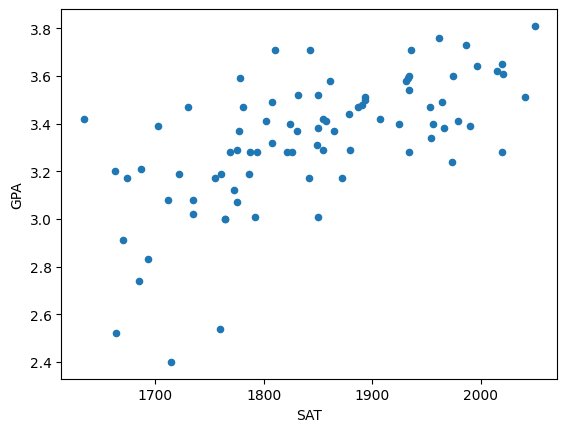

In [5]:
import pandas as pd
# SCATTER PLOT panfas
data.plot(kind='scatter',x='SAT',y='GPA')

Based on the result, visually we know that between SAT and GPA form linear relatonship, because more higher SAT score in x axis, more high GPA value. But its not enough to decide our assumption is right. So we should validate it by fitting the model linear to the data

#### Fit Model

Univariate linear regression uses the following model. Since we only have one input variable (x) and one output variable (y), the relationship can **be** visualized in a 2D plane. If we assume the relationship is linear, we can model it using a linear equation.


##### Formula

Linear Equation

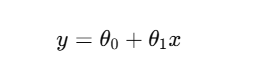

- y is outcome variable that we want to predict
- Θ<sub>0</sub> is a intercept when x = 0,  the start position of line (intersect with y-axis)
- Θ<sub>1</sub> is slope of the line
  - when Θ<sub>1</sub> large is when the x is small and the y is large, extreem slope line
  - Otherwise Θ<sub>1</sub> small, y is small and x is larger

The best model is the one with the smallest prediction error. In linear regression, we find the best slope and intercept so that the residual errors are as small as possible

And next we prepared value for slope and intercept using minimum and maximum value

In linear equatin, to search slope we can use this formula

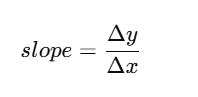

So, we want to make a range a value of slope used using random data point in datasat

In [14]:
point_1 = data.iloc[0]
point_2 = data.iloc[1]

slope =  (point_2['GPA'] - point_1['GPA']) / (point_2['SAT'] - point_1['SAT'])
print(slope + 0.002)
print(slope - 0.002)

-0.0004000000000000019
-0.004400000000000002


And Intercept

In [15]:
intercept_1 = point_1['GPA'] - (slope * point_1['SAT'])
print(intercept_1 + 0.002)
print(intercept_1 - 0.002)

6.515600000000004
6.511600000000004


We get range of value:
- Slope between -0.004400000000000002 and -0.0004000000000000019
- Intecept between 6.515600000000004 and 6.511600000000004

Then, we start searching for possible slope and intercept values within a selected range. For each pair of slope and intercept, we predict y using each x value. However, this method can be time-consuming and inefficient. Also, looking at the residual from only one data point is not enough, because the residual may be small for one point but large for another. Therefore, we need a rule to measure how well the model fits all data points. In linear regression, this rule is called the **cost function**.

##### Cost Function
Cost Function will help user to determine best fit model for relationship between x and y variable

Formula

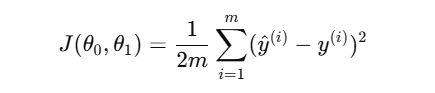

Step to find cost function:

In [19]:
# for example we use slope = -0.004400000000000002  and intercept 6.511600000000004
slope = -0.004400000000000002
inter = 6.511600000000004

# find y_predict
data['y_predict'] = (slope * data['SAT']) + (inter)

# find error
data['residual'] = data['y_predict'] - data['GPA']

# find SSE
data['SSE'] = data['residual']**2

# cost function
cost_function  = data['SSE'].sum() / (2*len(data))
print(f"cost function for slope : {slope} and intercept:{inter} is {cost_function}")

cost function for slope : -0.004400000000000002 and intercept:6.511600000000004 is 12.410759094285714


From code above, we find cost function for one slope and one intercept, so we should find cost function for all possible value slope and intercept range value, it lead time-consuming. **Therefore, we can find the best slope and intercept or best fit model efficiently using gradient descent**

##### Gradient Descent
An iterative method to find best slope and intercept by producing minimum cost function.

Recall formula in cost function:

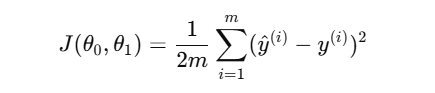

From image we see the cost function/MSE have quadratic form, when we draw in 2D plane using intercept and slope range value, it will create **convex** form. How to find minimun cost function? we can using **gradient descent**

Gradient descent will stop the process:
- reach max iterative
- the change of cost function is small
- gradient descent closest to zero

Before we implement gradient descent, we shoudl scale the x variable, most common method using standarization z-score

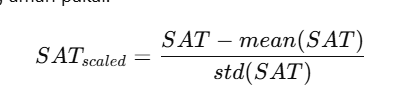

In [21]:
z_score_SAT = (data['SAT'] - data['SAT'].mean())/data['SAT'].std()
z_score_SAT.head()

,SAT
0,-1.255840
1,-1.734169
2,-0.815778
3,-1.533271
4,-1.456738


and then start to use gradient descent

In [23]:
slope_init = 0
inter_init = 0
learning_rate = 0.01
best_val = []
prev_cost = float('inf')

#epsolon
epsilon = 1e-6

for i in range(1,1000):
  sat_val = z_score_SAT.copy()
  gpa_val = data['GPA'].copy()
  #y_predict
  y_predict  = slope_init*sat_val + inter_init
  #error
  error = y_predict - gpa_val
  #sse
  sse = (error)**2
  cost =  sse.sum()/(2*len(gpa_val))

  # gradient
  d_slope = (error*sat_val).sum()/len(gpa_val)
  d_inter = (error.sum())/len(gpa_val)

  slope_init = slope_init - (learning_rate * d_slope)
  inter_init = inter_init - (learning_rate * d_inter)

  if(abs(prev_cost - cost) < epsilon) or (abs(d_slope) < epsilon and abs(d_inter) < epsilon):
    best_val.append((slope_init,inter_init))
    print(f"\nbest slope : {slope_init}")
    print(f"\nbest intercept : {inter_init}")

    print(f"\niteratuon stop at {i}")
    break

  # update cost
  prev_cost = cost








best slope : 0.17252450479183565

best intercept : 3.3204457176543394

iteratuon stop at 580


Explanation:
- before we doing gradiend descent, we should decide initial value for
  - slope
  - intercept
  - learning rate (value to set how big is change from previous slope to new slope value). smalles learning rate means slowly searching and bigger value means will lead incosistent result
  - epsilon (parameter that we should reach to stop gradient descent)

- Formula d_slope and d_intercept:


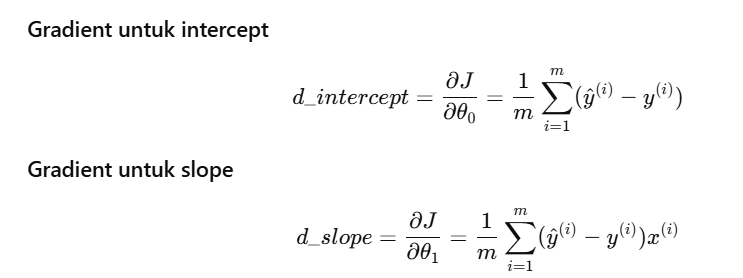

#### Asumption Test
There're four test that assumption of linear is valid:
1. residual error plot should spread randomly
2. residual plot should Normal shape
3. Homoscedasticity
4. No extrem Outlier

##### Residual Error Plot

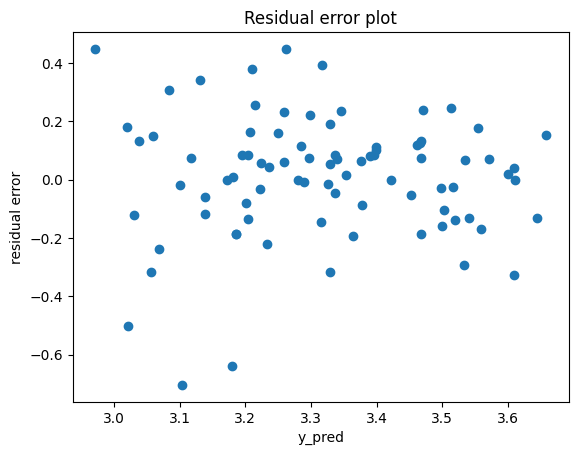

In [34]:
# y_predict using best slope and intercept, and usinf zscore
best_slope,best_intercept = best_val[0]
y_predict =  best_slope * z_score_SAT + best_intercept
#residual
residual_error  = data['GPA'] - y_predict
from matplotlib import pyplot as plt
plt.scatter(y_predict,residual_error)
plt.xlabel('y_pred')
plt.title('Residual error plot')
plt.ylabel('residual error')
plt.show()

The residuals are randomly scattered around zero, indicating that there is no clear hidden pattern left in the errors. This suggests that the linear model fits the data reasonably well. In this step to find residual we use difference between y_actual  and y_prediction That different with cost fucntion (y_pred- y_actual). Both are same but in this test we use y_actual -  y_pred.

##### Homoscedasticity

Variance of residual should constant given by y prediction result

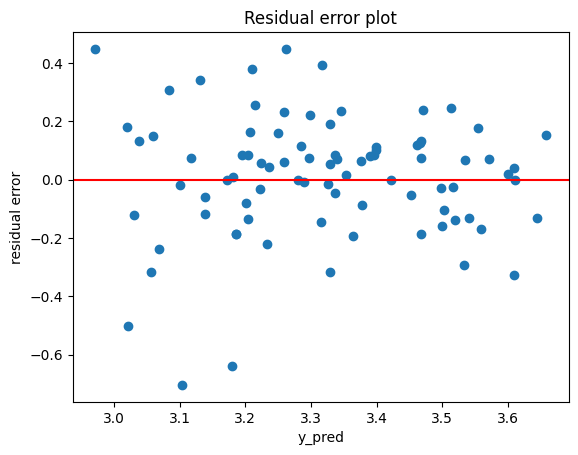

In [35]:
plt.scatter(y_predict,residual_error)
plt.xlabel('y_pred')
plt.title('Residual error plot')
plt.axhline(0,color='r')
plt.ylabel('residual error')
plt.show()

Based on the result, in the left, center, and right have same spread width given y prediction, so The residual spread appears relatively consistent across the predicted values, with no strong funnel-shaped pattern. This suggests that the homoscedasticity assumption is reasonably satisfied, although a few outliers are present.

Also there're few extrem outlier in residual error means that linear assumption can be used for this problem

## Conclusion

assumptuin test using scatter there're linear form between GPA and SAT score, and then we validate using best slope and intercept from gradient descent method and doing some test like create residual plot and homodesicisity. Based on the result, in the left, center, and right have same spread width given y prediction, so The residual spread appears relatively consistent across the predicted values, with no strong funnel-shaped pattern. This suggests that the homoscedasticity assumption is reasonably satisfied, although a few outliers are present.

Also there're few extrem outlier in residual error means that linear assumption can be used for this problem